# import moduls

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,roc_curve,auc,RocCurveDisplay,balanced_accuracy_score,classification_report
from imblearn.over_sampling import SMOTE

# create dataset

In [2]:
np.random.seed(42)
class_1 = np.random.normal(loc=0,scale=0.5,size=900)
y_1 = np.zeros_like(class_1).astype(int)

class_2 = np.random.normal(loc=2,scale=0.5,size=100)
y_2 = np.ones_like(class_2).astype(int)

X , y = np.concatenate((class_1,class_2),axis=0) , np.concatenate((y_1,y_2),axis =0)

df = pd.DataFrame(data= {
    "X":X,
    "y":y
})
df = shuffle(df)
df.reset_index(drop=True,inplace=True)

display(df.head(10))

Xtrain, Xtest, ytrain, ytest = train_test_split(df.iloc[:,:-1],df.iloc[:,1],test_size=0.3,stratify=df.iloc[:,1],random_state=42)


,X,y
0,-0.564853,0
1,0.307083,0
2,-0.428579,0
3,0.037902,0
4,0.369233,0
5,0.410241,0
6,-0.109836,0
7,0.029104,0
8,-0.243563,0
9,-0.229680,0


# fit model 

In [3]:
clf = LogisticRegression()
clf.fit(Xtrain,ytrain)
prob = clf.predict_proba(Xtest)[:,1]
predict = clf.predict(Xtest)

cm = confusion_matrix(y_true=ytest,y_pred=predict)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
b_acc = balanced_accuracy_score(y_true=ytest,y_pred=predict)
clf_report = classification_report(y_pred=predict,y_true=ytest)

fpr,tpr,thresholds = roc_curve(y_score=prob,y_true=ytest)
roc_auc = auc(fpr,tpr)
Rdsp = RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)

Xtrain.shape

(700, 1)

# plots and outputs

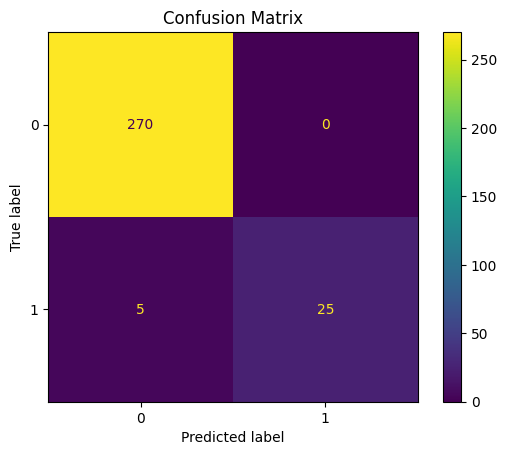

➖➖➖➖➖
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       270
           1       1.00      0.83      0.91        30

    accuracy                           0.98       300
   macro avg       0.99      0.92      0.95       300
weighted avg       0.98      0.98      0.98       300

Balanced Accuracy : 0.9166666666666667


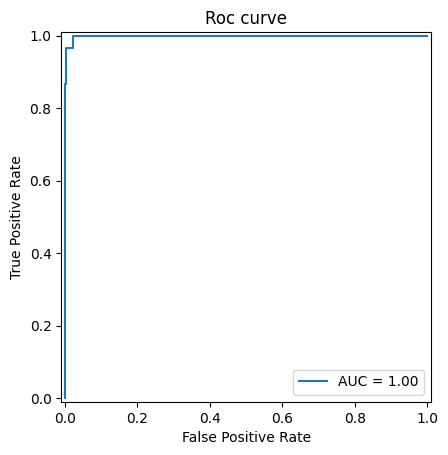

In [4]:
dsp.plot()
plt.title('Confusion Matrix')
plt.show()
print(f"➖➖➖➖➖\n{clf_report}")
print(f"Balanced Accuracy : {b_acc}")
Rdsp.plot()
plt.title('Roc curve')
plt.show()


# SMOTE

In [5]:
sm = SMOTE(random_state=42,sampling_strategy='minority')
Xtrain_sm,ytrain_sm = sm.fit_resample(Xtrain,ytrain,)

clf = LogisticRegression()
clf.fit(Xtrain_sm,ytrain_sm)
prob = clf.predict_proba(Xtest)[:,1]
predict = clf.predict(Xtest)

cm = confusion_matrix(y_true=ytest,y_pred=predict)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
b_acc = balanced_accuracy_score(y_true=ytest,y_pred=predict)
clf_report = classification_report(y_pred=predict,y_true=ytest)

fpr,tpr,thresholds = roc_curve(y_score=prob,y_true=ytest)
roc_auc = auc(fpr,tpr)
Rdsp = RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)

Xtrain_sm.shape

(1260, 1)

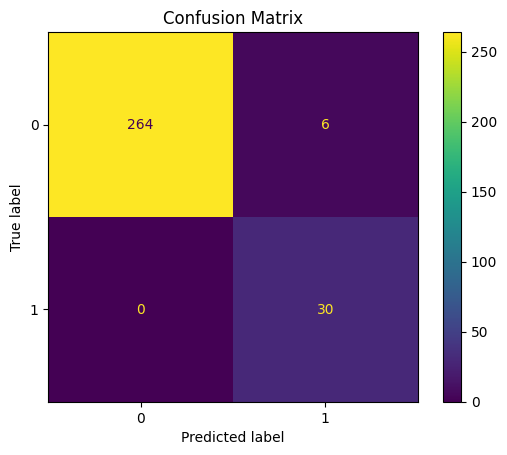

➖➖➖➖➖
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       270
           1       0.83      1.00      0.91        30

    accuracy                           0.98       300
   macro avg       0.92      0.99      0.95       300
weighted avg       0.98      0.98      0.98       300

Balanced Accuracy : 0.9888888888888889


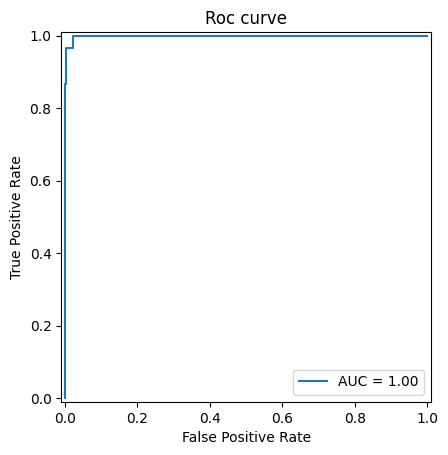

In [6]:
dsp.plot()
plt.title('Confusion Matrix')
plt.show()
print(f"➖➖➖➖➖\n{clf_report}")
print(f"Balanced Accuracy : {b_acc}")
Rdsp.plot()
plt.title('Roc curve')
plt.show()


# Change threshold to 0.3

In [7]:
predict = (prob > 0.3).astype(int)

cm = confusion_matrix(y_true=ytest,y_pred=predict)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
b_acc = balanced_accuracy_score(y_true=ytest,y_pred=predict)
clf_report = classification_report(y_pred=predict,y_true=ytest)

fpr,tpr,thresholds = roc_curve(y_score=prob,y_true=ytest)
roc_auc = auc(fpr,tpr)
Rdsp = RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)

Xtrain_sm.shape

(1260, 1)

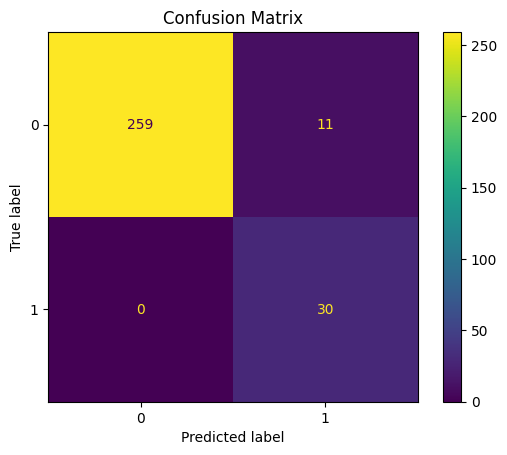

➖➖➖➖➖
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       270
           1       0.73      1.00      0.85        30

    accuracy                           0.96       300
   macro avg       0.87      0.98      0.91       300
weighted avg       0.97      0.96      0.97       300

Balanced Accuracy : 0.9796296296296296


In [8]:
dsp.plot()
plt.title('Confusion Matrix')
plt.show()
print(f"➖➖➖➖➖\n{clf_report}")
print(f"Balanced Accuracy : {b_acc}")


#  Concept Drift

In [9]:
clf = LogisticRegression()
clf.fit(Xtrain_sm,ytrain_sm)
Xtest_d = Xtest.copy(deep=True)
Xtest_d = Xtest_d*1.1
print(Xtest.mean(),'\nvar',Xtest.var(),"\n")
print(Xtest_d.mean(),'\nvar',Xtest_d.var(),"\n")

prob = clf.predict_proba(Xtest_d)[:,1]
predict = clf.predict(Xtest_d)

cm = confusion_matrix(y_true=ytest,y_pred=predict)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
b_acc = balanced_accuracy_score(y_true=ytest,y_pred=predict)
clf_report = classification_report(y_pred=predict,y_true=ytest)





X    0.246564
dtype: float64 
var X    0.58242
dtype: float64 

X    0.27122
dtype: float64 
var X    0.704729
dtype: float64 



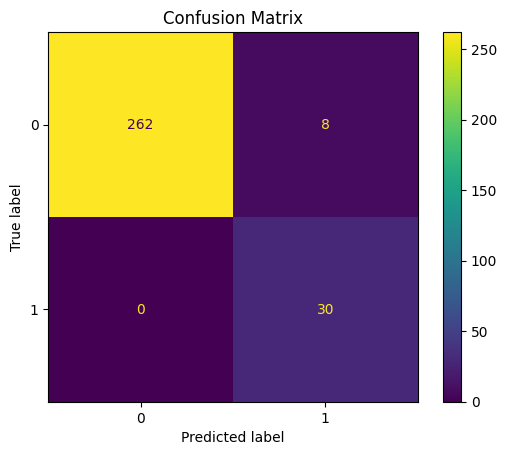

➖➖➖➖➖
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       270
           1       0.79      1.00      0.88        30

    accuracy                           0.97       300
   macro avg       0.89      0.99      0.93       300
weighted avg       0.98      0.97      0.97       300

Balanced Accuracy : 0.9851851851851852


In [10]:
dsp.plot()
plt.title('Confusion Matrix')
plt.show()
print(f"➖➖➖➖➖\n{clf_report}")
print(f"Balanced Accuracy : {b_acc}")



ایجاد نمونه های جدید کمکی نمی کند به این خاطر که  اکس تست دچار رانش داده شده به علت ضرب شدن در 1.1 و نمونه جدید کمکی نمی کند چون مدل بهینه شده برای داده هایی که دچار دریفت نشده اند 